In [1]:
from pypot.dynamixel import DxlIO
from pypot.dynamixel.protocol.v1 import *

from glob import glob

ports = glob('/dev/ttyACM*')
assert len(ports) == 1

port = ports[0]
print('Connecting on port: {}'.format(port))
dxl_io = DxlIO(port)

poulpe_id = 42
N_AXIS = 2

Connecting on port: /dev/ttyACM1


In [2]:
dxl_io.flush()

In [3]:
ping_packet = DxlPingPacket(poulpe_id)
dxl_io._send_packet(ping_packet)

DxlStatusPacket(id=42, error=0, parameters=())

In [4]:
import struct

def read_current_pos():
    pos_packet = DxlReadDataPacket(poulpe_id, 50, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet)
    data = bytearray(resp.parameters)
    pos = struct.unpack(N_AXIS * 'f', data)
    return pos

read_current_pos()

(0.0, 0.0)

In [5]:
def read_current_vel():
    pos_packet = DxlReadDataPacket(poulpe_id, 51, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet)
    data = bytearray(resp.parameters)
    res = struct.unpack(N_AXIS * 'f', data)
    return res

read_current_vel()

(0.0, 0.0)

In [6]:
def read_current_torque():
    pos_packet = DxlReadDataPacket(poulpe_id, 52, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet)
    data = bytearray(resp.parameters)
    res = struct.unpack(N_AXIS * 'f', data)
    return res

read_current_torque()

(18.0, -40.0)

In [7]:
def read_target_position():
    pos_packet = DxlReadDataPacket(poulpe_id, 60, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet,wait_for_status_packet=True)
    data = bytearray(resp.parameters)
    pos = struct.unpack(N_AXIS * 'f', data)
    return pos

read_target_position()

(0.0, 0.0)

In [8]:
def read_axis_sensor():
    pos_packet = DxlReadDataPacket(poulpe_id, 90, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet,wait_for_status_packet=True)
    data = bytearray(resp.parameters)
    pos = struct.unpack(N_AXIS * 'f', data)
    return pos

read_axis_sensor()

(nan, 2.9745702743530273)

In [9]:
def write_target_position(target):
    p = DxlWriteDataPacket(poulpe_id, 60, struct.pack(N_AXIS * 'f', *target))
    resp = dxl_io._send_packet(p,wait_for_status_packet=True)
    return resp

write_target_position([0.5, 0.5])

DxlStatusPacket(id=42, error=0, parameters=())

In [10]:
def read_torque_enabled():
    p = DxlReadDataPacket(poulpe_id, 40, N_AXIS)
    resp = dxl_io._send_packet(p)
    data = bytearray(resp.parameters)
    torque = struct.unpack(N_AXIS * '?', data)
    return torque

read_torque_enabled()

(True, True)

In [11]:
def write_torque_enabled(torque):
    p = DxlWriteDataPacket(poulpe_id, 40, struct.pack(N_AXIS * '?', *torque))
    resp = dxl_io._send_packet(p)
    return resp

write_torque_enabled([False, False])

DxlStatusPacket(id=42, error=0, parameters=())

In [12]:
write_torque_enabled([True, True])

DxlStatusPacket(id=42, error=0, parameters=())

In [17]:
import time
import numpy as np

pos = []
send_target = []
read_target = []
axis_sensor = []

t0 = time.time()
freq=0.25
cur=read_current_pos()
while True:
    if time.time() - t0 > 10:
        break

    target = [
        np.radians(2*360.0) * np.sin(2 * np.pi * freq * (time.time()-t0)), 
        0,#np.radians(360.0) * np.sin(2 * np.pi * freq * (time.time()-t0)),
    ]
    write_target_position(target)
    
    send_target.append(target)
    time.sleep(0.001)
    cur=read_current_pos()
    pos.append(cur)
    read_target.append(cur)
    time.sleep(0.001)
    axis_sensor.append(read_axis_sensor())
    time.sleep(0.001)

In [15]:
np.array(send_target) - np.array(pos)

array([[-0.46514498, -0.50161159],
       [-0.24892214, -0.38963103],
       [-0.04572728, -0.28378639],
       ...,
       [-0.63332045, -0.00153398],
       [-0.65407412, -0.00153398],
       [-0.66568068, -0.00153398]])

In [16]:
write_torque_enabled([False, False])

DxlStatusPacket(id=42, error=0, parameters=())

In [27]:
np.array(send_target)

array([[ 0.2460933 ,  0.25287913],
       [ 1.09855796,  1.10358794],
       [ 1.94466394,  1.94928308],
       ...,
       [-2.01695047, -2.01529142],
       [-1.22021167, -1.2181461 ],
       [-0.42984446, -0.42827169]])

In [29]:
np.array(pos)

array([[ -1.03125,  -1.0625 ],
       [ -0.96875,  -0.96875],
       [ -0.71875,  -0.8125 ],
       ...,
       [-12.125  , -12.21875],
       [-11.46875, -11.5    ],
       [-10.75   , -10.84375]])

In [63]:
write_target_position([0.0,0.0])

DxlStatusPacket(id=42, error=0, parameters=())

In [58]:
read_target_position()

(0.0, 0.0)

In [59]:
read_current_pos()

(0.0, 0.0)

In [14]:
import matplotlib.pyplot as plt

In [15]:
%matplotlib notebook

In [46]:
#plt.plot(send_target)
plt.plot(np.array(pos)/25.05)

<IPython.core.display.Javascript object>


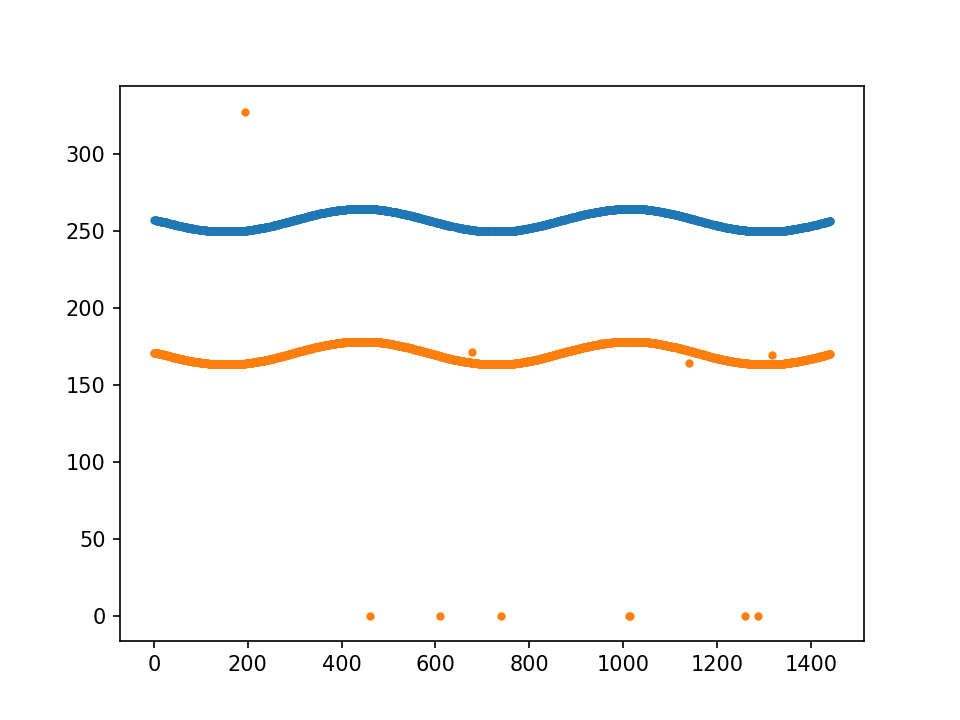

In [18]:
plt.plot(np.degrees(np.array(axis_sensor)), '.')

In [25]:
plt.savefig("sensors.pdf")

In [19]:
pos

[(0.0, 0.0),
 (0.01073786336928606, 0.0),
 (0.05522329360246658, 0.0),
 (0.10891260951757431, 0.0),
 (0.19021357595920563, 0.0),
 (0.2776504456996918, 0.0),
 (0.345145583152771, 0.0),
 (0.4479222893714905, 0.0),
 (0.5583688616752625, 0.0),
 (0.6442717909812927, -0.0015339803649112582),
 (0.7639222741127014, -0.0015339803649112582),
 (0.8866406679153442, -0.0015339803649112582),
 (1.0185630321502686, -0.0015339803649112582),
 (1.1428154706954956, -0.0015339803649112582),
 (1.2747377157211304, -0.0015339803649112582),
 (1.380582332611084, -0.0015339803649112582),
 (1.5094367265701294, -0.0015339803649112582),
 (1.6367571353912354, -0.0015339803649112582),
 (1.7763493061065674, -0.0015339803649112582),
 (1.9098056554794312, -0.0015339803649112582),
 (2.003378391265869, -0.0015339803649112582),
 (2.1445045471191406, -0.0015339803649112582),
 (2.288698673248291, -0.0015339803649112582),
 (2.3884074687957764, -0.0015339803649112582),
 (2.5172619819641113, -0.0030679607298225164),
 (2.6445822

In [3]:
import serial

In [4]:
s=serial.Serial("/dev/ttyACM0", 1000000, timeout=1)

In [5]:
s.read()

b''

In [16]:
def rawping():
    s.write(b'\xff\xff*\x02\x01\xd2')
    ret=s.read(6)
    print(ret)

In [20]:
rawping()

b'\x00\x00\x00\x00\x00\x00'


In [9]:
from pypot.dynamixel.protocol.v1 import *
ping_packet = DxlPingPacket(42)

In [10]:
ping_packet.to_string()

b'\xff\xff*\x02\x01\xd2'